In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

df = pd.read_parquet("../../data/processed/product_month_labeled.parquet")


[1/8] 정형 피처 분포 확인
       review_count    avg_rating  low_rating_ratio
count  68087.000000  68087.000000      68087.000000
mean      12.752229      4.239481          0.152245
std       18.997290      0.756117          0.192487
min        1.000000      1.000000          0.000000
25%        4.000000      3.875000          0.000000
50%        8.000000      4.428571          0.093458
75%       14.000000      4.833333          0.250000
max      686.000000      5.000000          1.000000


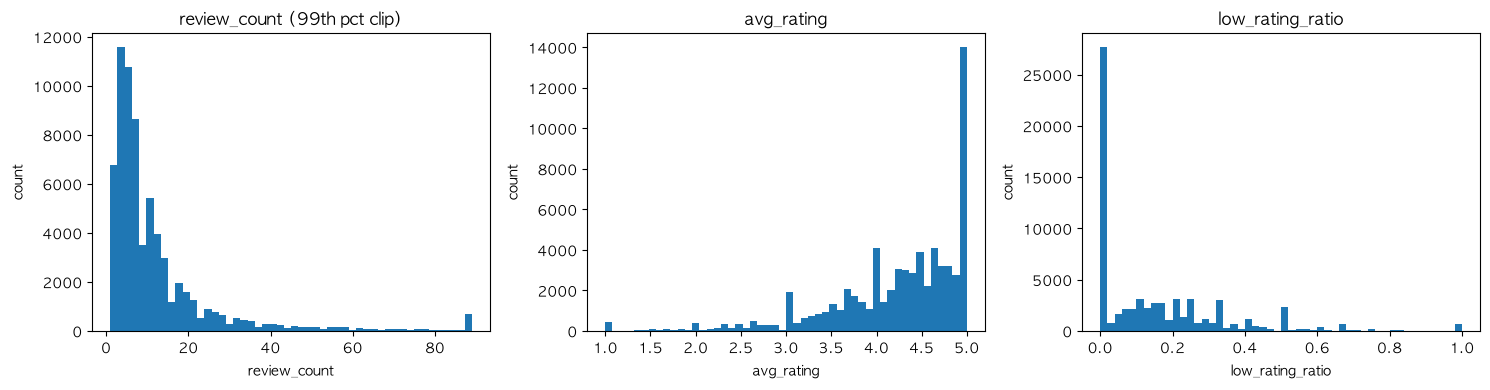

  예시: 평균평점 4.3~4.5 구간에서 low_rating_ratio가 가장 낮은 상품 B002DUCEO0(0.0%) vs 가장 높은 상품 B078BL25P3(20.0%)


In [3]:
# 1. 정형 피처 분포 확인

from eda import check_feature_distributions

check_feature_distributions(df)


[2/8] 월별 라벨 비율 시계열
       label_ratio       n_rows
count    86.000000    86.000000
mean      0.091415   791.709302
std       0.025599   244.547258
min       0.044872   419.000000
25%       0.072213   562.000000
50%       0.088415   809.500000
75%       0.110616   971.500000
max       0.145652  1424.000000


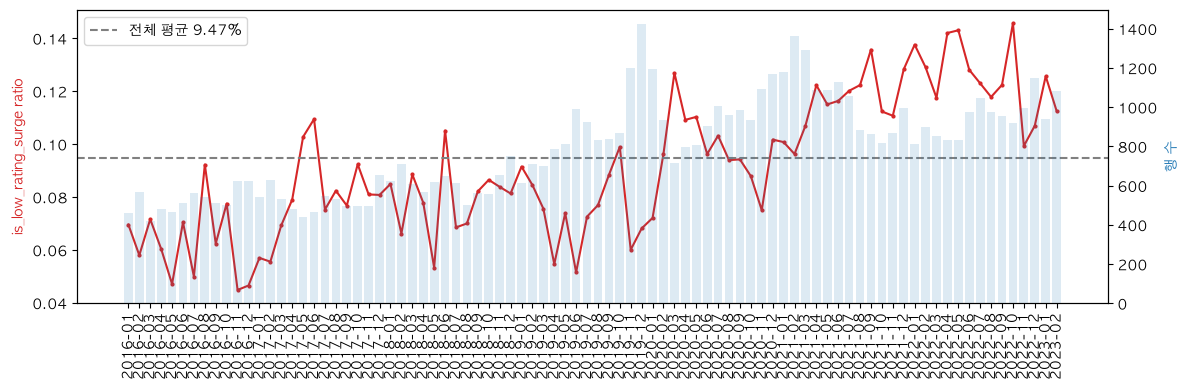

In [4]:
# 2. 월별 라벨 비율 시계열

from eda import check_monthly_label_trend

check_monthly_label_trend(df)


[3/8] 라벨 타당성 산점도 + 데이터 누수 재점검
  past_3m_low_rating_ratio vs next_low_rating_ratio Pearson corr = 0.575


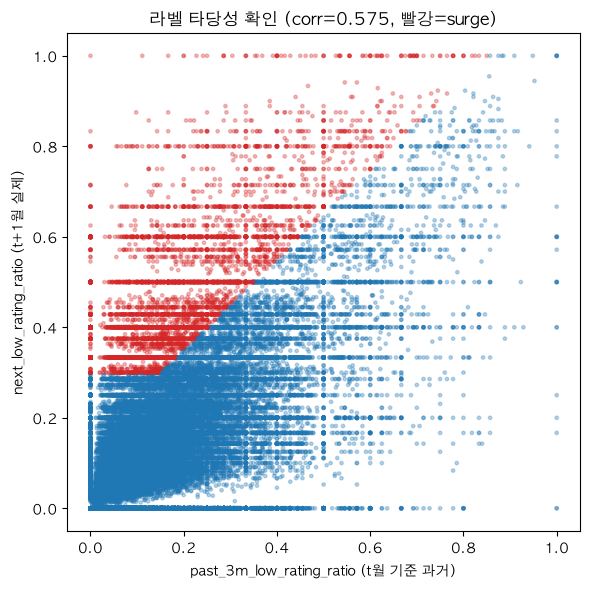

  [확인 완료] next_* 컬럼은 FEATURE_COLUMNS에 포함되어 있지 않습니다.


In [5]:
# 3. 라벨 타당성 산점도 + 데이터 누수 재점검

from eda import check_label_validity_scatter

check_label_validity_scatter(df)


[4/8] 입력 피처 상관관계 / 다중공선성 확인


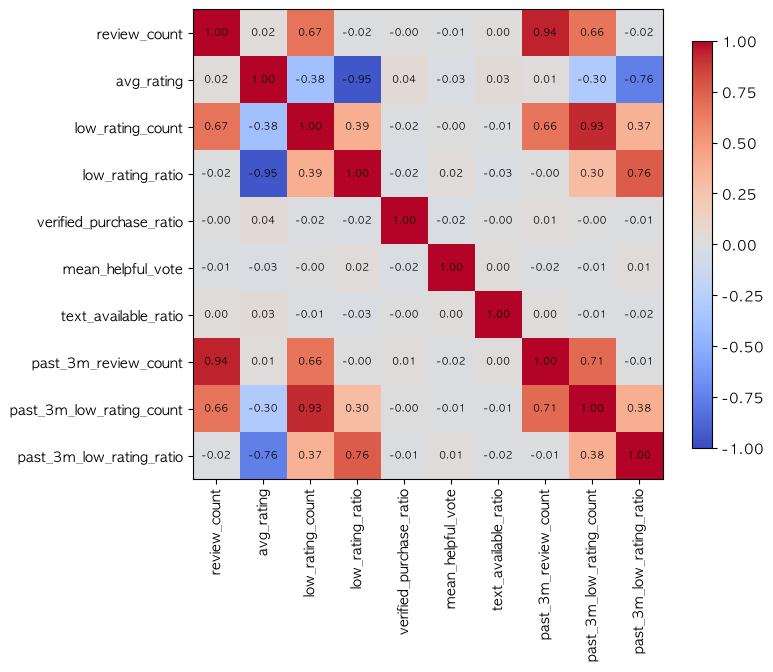

  상관계수 0.8 이상 쌍:
    review_count <-> past_3m_review_count : 0.940
    avg_rating <-> low_rating_ratio : -0.947
    low_rating_count <-> past_3m_low_rating_count : 0.927
                 feature        VIF
    text_available_ratio 435.342815
              avg_rating 302.645576
 verified_purchase_ratio  93.064046
    past_3m_review_count  18.682103
            review_count  16.781335
        low_rating_ratio  16.764969
past_3m_low_rating_count  16.049874
        low_rating_count  14.661370
past_3m_low_rating_ratio   6.609751
       mean_helpful_vote   1.032158
  [주의] VIF 5 초과 피처 존재 (statsmodels 권장 기준): ['text_available_ratio', 'avg_rating', 'verified_purchase_ratio', 'past_3m_review_count', 'review_count', 'low_rating_ratio', 'past_3m_low_rating_count', 'low_rating_count', 'past_3m_low_rating_ratio'] -> 베이스라인 모델링 때 피처 통합/제거 고려


In [6]:
# 4. 입력 피처 상관관계 / 다중공선성 (VIF)

from eda import check_correlation_multicollinearity

check_correlation_multicollinearity(df)


[5/8] 데이터 신뢰도 피처 (Wilson score interval)
count    68087.000000
mean         0.445961
std          0.174025
min          0.011753
25%          0.319429
50%          0.434482
75%          0.561497
max          0.810938


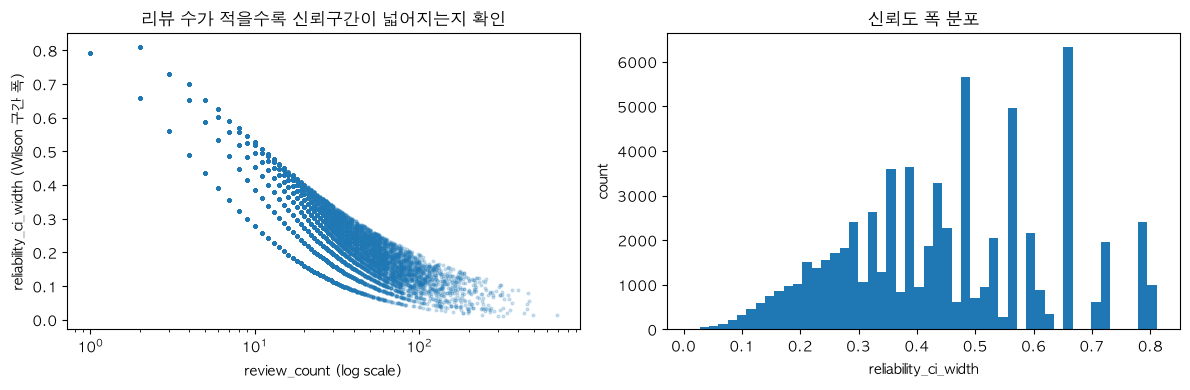


  위험(surge=1)하지만 신뢰구간이 가장 넓은(=근거가 얕은) 상위 5건:
parent_asin year_month  review_count  low_rating_ratio  reliability_ci_width
 B01LWP7LUQ    2019-02             2               0.5              0.810938
 B00N9AWVHS    2018-01             2               0.5              0.810938
 B00LTXYPCG    2017-08             2               0.5              0.810938
 B00DM8KQ2Y    2020-06             2               0.5              0.810938
 B087D8MZCS    2022-01             2               0.5              0.810938


In [7]:
# 5. 데이터 신뢰도 피처 (Wilson score interval)

from eda import check_reliability_features

df = check_reliability_features(df) 


[6/8] 나머지 피처 분포 확인
       verified_purchase_ratio  mean_helpful_vote  text_available_ratio
count             68087.000000       68087.000000          68087.000000
mean                  0.970740           1.012012              0.998962
std                   0.100933           5.922871              0.014696
min                   0.000000           0.000000              0.000000
25%                   1.000000           0.000000              1.000000
50%                   1.000000           0.142857              1.000000
75%                   1.000000           0.636364              1.000000
max                   1.000000         833.857143              1.000000


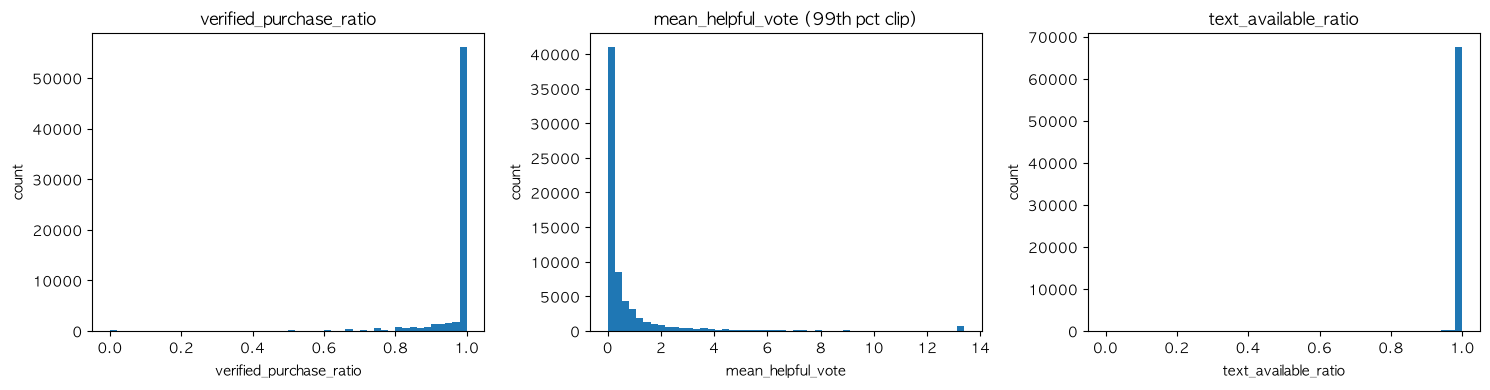


  text_available_ratio == 0 (리뷰 본문 전혀 없음): 0.00%
  text_available_ratio < 0.5 (본문 있는 리뷰가 절반 미만): 0.00%


In [8]:
# 6. 나머지 피처 분포 확인 (verified_purchase_ratio, mean_helpful_vote, text_available_ratio)

from eda import check_remaining_feature_distributions

check_remaining_feature_distributions(df)


[7/8] review_count 구간별 라벨 비율
                     label_ratio  n_rows
review_count_bucket                     
0-9                     0.113699   41267
10-29                   0.075333   21186
30-99                   0.030113    5114
100+                    0.011538     520


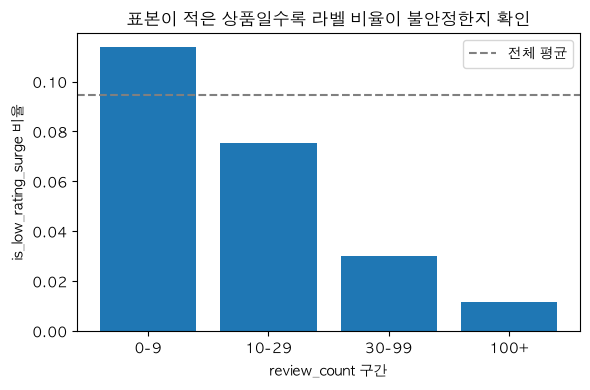

In [9]:
# 7. review_count 구간별 라벨 비율

from eda import check_label_ratio_by_review_count_bucket

check_label_ratio_by_review_count_bucket(df)

In [10]:
# 8. 이상치 / 극단값 점검

from eda import check_outliers

check_outliers(df)


[8/8] 이상치 / 극단값 점검
  avg_rating == 5.0 (만점 고정): 13,280건
  avg_rating == 1.0 (최저점 고정): 454건
  review_count>=100 인데 low_rating_ratio==0: 14건
parent_asin year_month  review_count  low_rating_ratio
 B0B3DB5HTC    2016-10           101               0.0
 B0B3DB5HTC    2017-06           114               0.0
 B0B3DB5HTC    2017-07           184               0.0
 B0B3DB5HTC    2018-01           160               0.0
 B0B3DB5HTC    2018-09           126               0.0

  verified_purchase_ratio < 0.1 인 행 비율: 0.41%
